# P15 — Engenharia de Dados e ML para vendas de açaí
Projeto Integrador realizado individualmente.

**Justificativa:** Optei pela realização individual do Projeto Integrador em razão dos meus horários de trabalho como docente em duas faculdades, que dificultam a conciliação de agendas para o desenvolvimento em equipe.

Objetivo: estimar a quantidade vendida por transação, considerando o contexto conhecido antes da venda. As vendas são fictícias; este trabalho demonstra o pipeline acadêmico, sem comprovar previsão de demanda real.

Fluxo: duas fontes → PostgreSQL raw → ETL Python → PostgreSQL relacional → EDA → features causais → regressão → métricas.

## Fontes e reprodução
1. Base fictícia M3: vendas CSV, clientes JSON e produtos CSV. Os três arquivos têm a mesma origem e contam como uma fonte.
2. API de Localidades do IBGE: cadastro real de cinco municípios, coletado via HTTPS e preservado como JSON com data e SHA256. Documentação: https://servicodados.ibge.gov.br/api/docs/localidades.

Execute após instalar requirements.txt e definir P15_DATABASE_URL. O snapshot incluído permite reproduzir sem nova consulta externa. Para nova coleta, use `python -m src.executar --atualizar-ibge`.

O cadastro é uma consulta retrospectiva atual, não uma fotografia territorial de 2025. A região imediata é contexto geográfico estático; não incorpora vendas ou targets futuros.

In [1]:
from pathlib import Path
import os,sys,json
import pandas as pd
from IPython.display import display,Image
ROOT=Path.cwd()
if not (ROOT/'src').exists(): ROOT=ROOT.parent
assert (ROOT/'src').exists()
sys.path.insert(0,str(ROOT))
assert os.environ.get('P15_DATABASE_URL'), 'Defina P15_DATABASE_URL'

## Executar o fluxo completo
O pipeline coleta/verifica o snapshot, insere as duas fontes no raw PostgreSQL, relê os dados para o ETL, normaliza, registra rejeições, integra município+UF com o IBGE e grava tabelas com chaves estrangeiras. A view dataset_ml é relida e conferida campo a campo antes de alimentar EDA e treinamento. Apenas as tabelas do schema p15 são recarregadas, em uma transação.

In [2]:
from src.executar import main
metricas=main(ROOT)

VALIDACAO Ridge


VALIDACAO RandomForest


VALIDACAO HistGradientBoosting


VALIDACAO BaselineMedia


MODELOS: {
  "target": "quantidade",
  "selecao": "Menor MAE medio dos 3 folds temporais, entre os 3 modelos ML; baseline separado.",
  "modelo_selecionado": "RandomForest",
  "seed": 42,
  "treino_n": 476,
  "teste_n": 116,
  "treino_inicio": "2025-01-01",
  "treino_fim": "2025-10-16",
  "teste_inicio": "2025-10-17",
  "teste_fim": "2025-12-31",
  "features_numericas": 18,
  "campos_categoricos": 6,
  "features_apos_encoding": 43,
  "comparacao": [
    {
      "modelo": "Ridge",
      "CV_MAE_media": 3.160291551715375,
      "CV_MAE_desvio": 0.17527045173556985,
      "MAE": 2.788391519208226,
      "RMSE": 3.4455617974395656,
      "R2": -0.331468289627878,
      "selecionado_por_CV": false
    },
    {
      "modelo": "RandomForest",
      "CV_MAE_media": 3.0753163524010865,
      "CV_MAE_desvio": 0.06703692947042239,
      "MAE": 2.618156032600295,
      "RMSE": 3.2223268667296945,
      "R2": -0.16452797329084268,
      "selecionado_por_CV": true
    },
    {
      "modelo": "Hist

P15 concluída; PostgreSQL e duas fontes integradas.


In [3]:
fontes=json.loads((ROOT/'dados/fontes.json').read_text(encoding='utf8'))
display(fontes)

{'ibge': {'url': 'https://servicodados.ibge.gov.br/api/v1/localidades/municipios/1600303|1600600|1501402|1506807|1302603',
  'documentacao': 'https://servicodados.ibge.gov.br/api/docs/localidades',
  'coletado_em_utc': '2026-10-03T20:54:22.487421+00:00',
  'metodo': 'GET HTTPS; resposta JSON original preservada',
  'sha256': 'ba4f40aa3da933efee7a726902e276885bd89f35744543416bc80c17ac77fe6a',
  'registros': 5},
 'm3': {'origem': 'Base fictícia da atividade M3, reutilizada da M5',
  'metodo': 'Cópia local dos arquivos originais, sem alterar bytes',
  'natureza': 'Vendas, clientes e produtos simulados; uma única origem',
  'arquivos': {'vendas.csv': 'dcd81c0e2639f112c3e3cb93dd5665bfe095fec2e62e7c151d38f30a5f593ef2',
   'clientes.json': '46cc431265ac65fbcc05bcf1168be2f6ee4f25e48047a6e90f6635e413fabb0f',
   'produtos.csv': '9022b0e74cf47c39f53c36b26cd0c3a13036446a64b58dae120b6f8a83f30cdf'}}}

## Modelagem e qualidade
Tabelas fontes e raw preservam a procedência e os registros originais. Clientes, produtos e municípios são dimensões; vendas contém suas chaves e restrições de quantidade, preço e valor total. Rejeitadas conserva ordem e motivo. A limpeza aceita somente registros válidos, preserva a primeira ocorrência válida por ID e não imputa quantidade ou preço.

A view integra as tabelas para uso analítico. O valor total é usado apenas em EDA; não entra nas features.

In [4]:
display(json.loads((ROOT/'resultados/postgresql.json').read_text(encoding='utf8')))
display(json.loads((ROOT/'resultados/metricas_limpeza.json').read_text(encoding='utf8')))
df=pd.read_csv(ROOT/'dados/vendas_integradas.csv')
display(df.head())
display(df.groupby(['municipio','uf','municipio_id','regiao_imediata']).size().rename('vendas').reset_index())

{'executado': True,
 'versao': 'PostgreSQL 17.11 on x86_64-windows, compiled by msvc-19.44.35228, 64-bit',
 'schema': 'p15',
 'registros': 592,
 'receita': '130405.70',
 'raw_releitura_igual': True,
 'dataset_releitura_igual': True,
 'municipios_ibge': 5,
 'vendas_integradas_ibge': 592,
 'commit_confirmado': True}

{'antes': {'registros': 740,
  'ausentes_por_coluna': {'venda_id': 0,
   'cliente_id': 0,
   'produto_id': 0,
   'data': 0,
   'municipio': 0,
   'uf': 0,
   'quantidade': 0,
   'preco_unitario': 21},
  'duplicatas_linha_completa': 20,
  'duplicatas_id_normalizado': 20,
  'inconsistencias_independentes': {'quantidade_invalida': 37,
   'data_invalida': 30,
   'cliente_desconhecido': 22,
   'preco_invalido': 21,
   'produto_desconhecido': 19}},
 'depois': {'registros': 592,
  'ausentes_por_coluna': {'uf': 0,
   'data': 0,
   'venda_id': 0,
   'municipio': 0,
   'cliente_id': 0,
   'produto_id': 0,
   'quantidade': 0,
   'preco_unitario': 0,
   'valor_total': 0,
   'segmento': 0,
   'categoria': 0},
  'duplicatas_id': 0,
  'receita': 130405.7},
 'rejeitadas': 148,
 'motivos_exclusivos': {'quantidade_invalida': 37,
  'data_invalida': 30,
  'cliente_desconhecido': 22,
  'preco_invalido': 21,
  'produto_desconhecido': 19,
  'duplicada': 19},
 'campos_normalizados_em_linhas_aceitas': {'venda_

,venda_id,cliente_id,produto_id,data,municipio,uf,quantidade,preco_unitario,valor_total,segmento,categoria,municipio_id,regiao_imediata
0,V0456,C014,P02,2025-01-01,Macapá,AP,2,12.5,25.0,restaurante,congelados,1600303,Macapá
1,V0275,C014,P01,2025-01-02,Belém,PA,2,18.9,37.8,restaurante,congelados,1501402,Belém
2,V0451,C005,P03,2025-01-02,Belém,PA,6,12.5,75.0,restaurante,atacado,1501402,Belém
3,V0088,C053,P05,2025-01-03,Santarém,PA,12,25.0,300.0,restaurante,complementos,1506807,Santarém
4,V0191,C013,P01,2025-01-03,Santarém,PA,5,18.9,94.5,atacado,congelados,1506807,Santarém


,municipio,uf,municipio_id,regiao_imediata,vendas
0,Belém,PA,1501402,Belém,120
1,Macapá,AP,1600303,Macapá,133
2,Manaus,AM,1302603,Manaus,118
3,Santana,AP,1600600,Macapá,96
4,Santarém,PA,1506807,Santarém,125


## Análise exploratória
A EDA descreve a base e suas rejeições. A separação temporal, os algoritmos e os parâmetros são definidos pelo protocolo reutilizado da M5. As correlações usadas para descrever features são calculadas somente no treino; nenhuma escolha é feita com o teste.

,quantidade,preco_unitario,valor_total
count,592.000000,592.000000,592.000000
mean,6.528716,33.794595,220.279899
std,3.436519,17.857917,176.222962
min,1.000000,12.500000,12.500000
25%,4.000000,18.900000,94.500000
50%,6.000000,32.400000,170.100000
75%,9.250000,45.500000,300.000000
max,12.000000,65.000000,780.000000


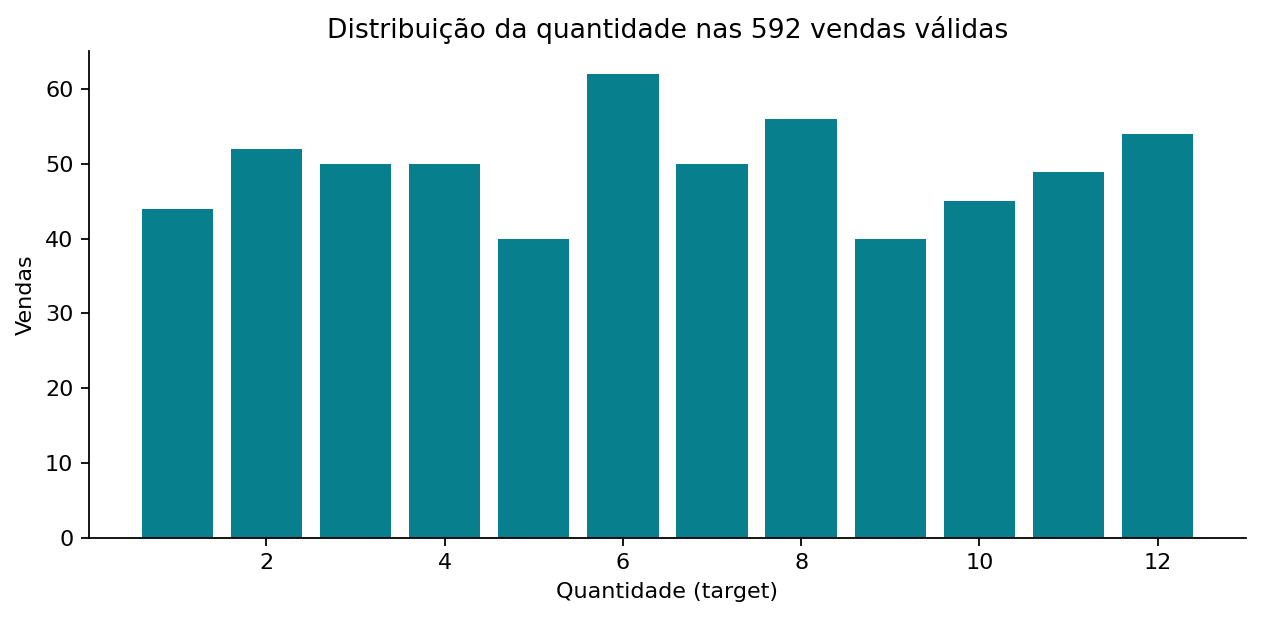

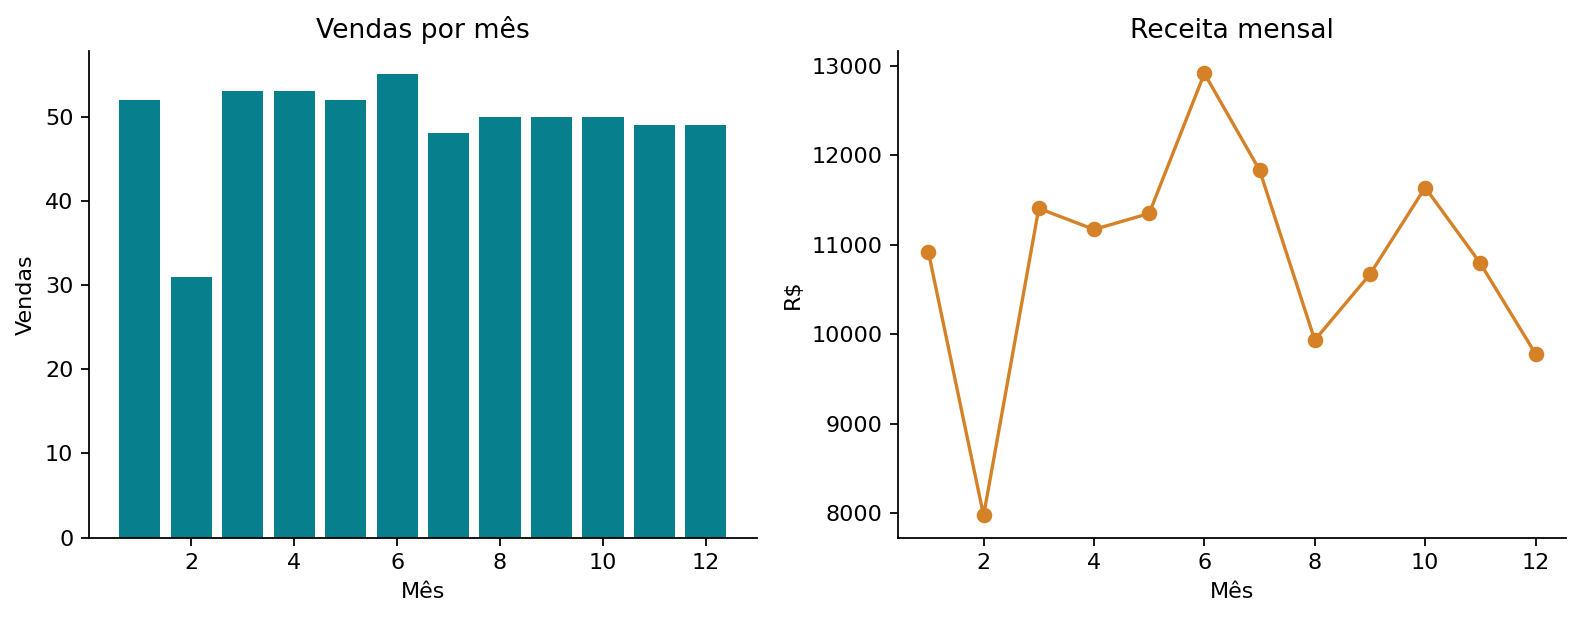

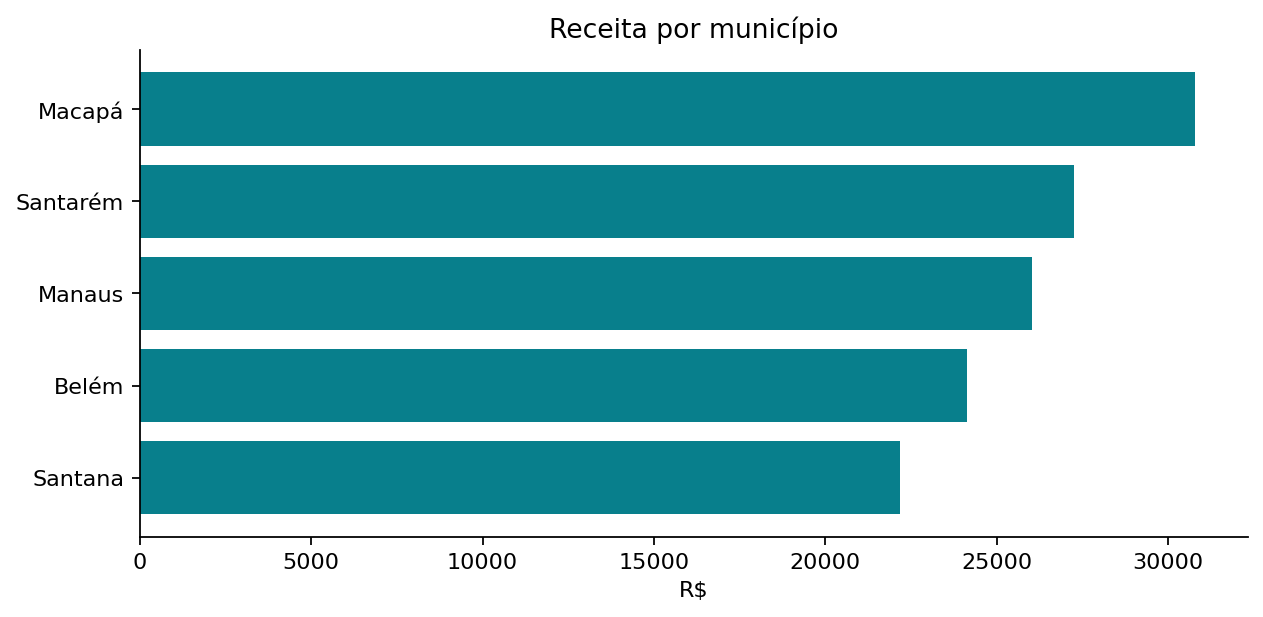

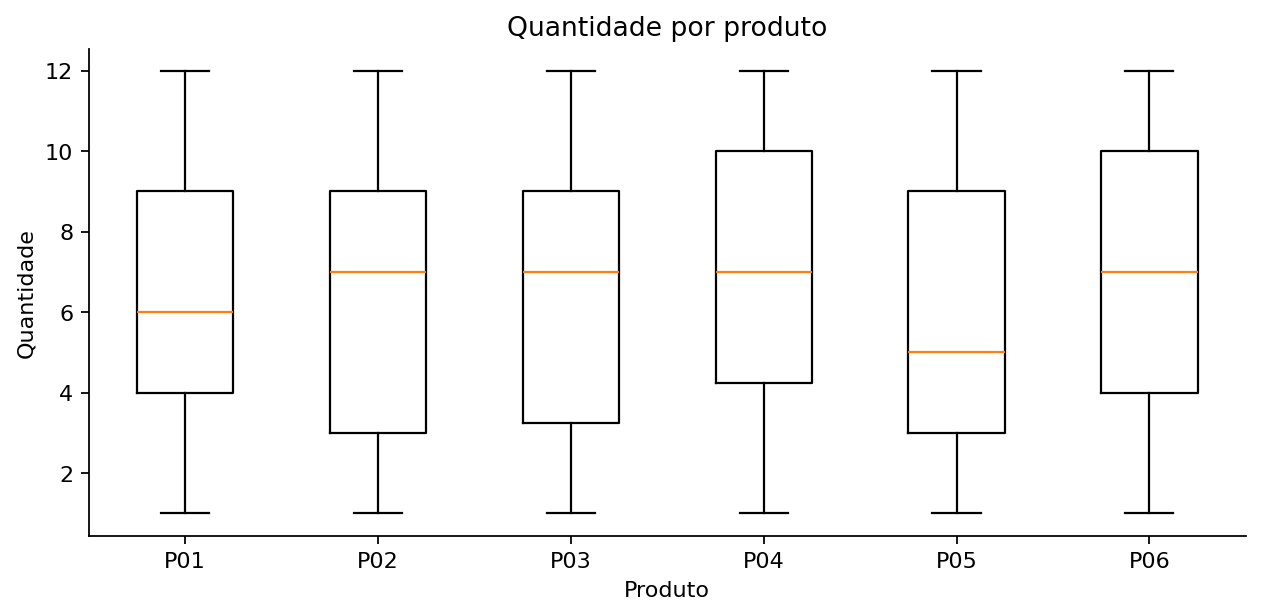

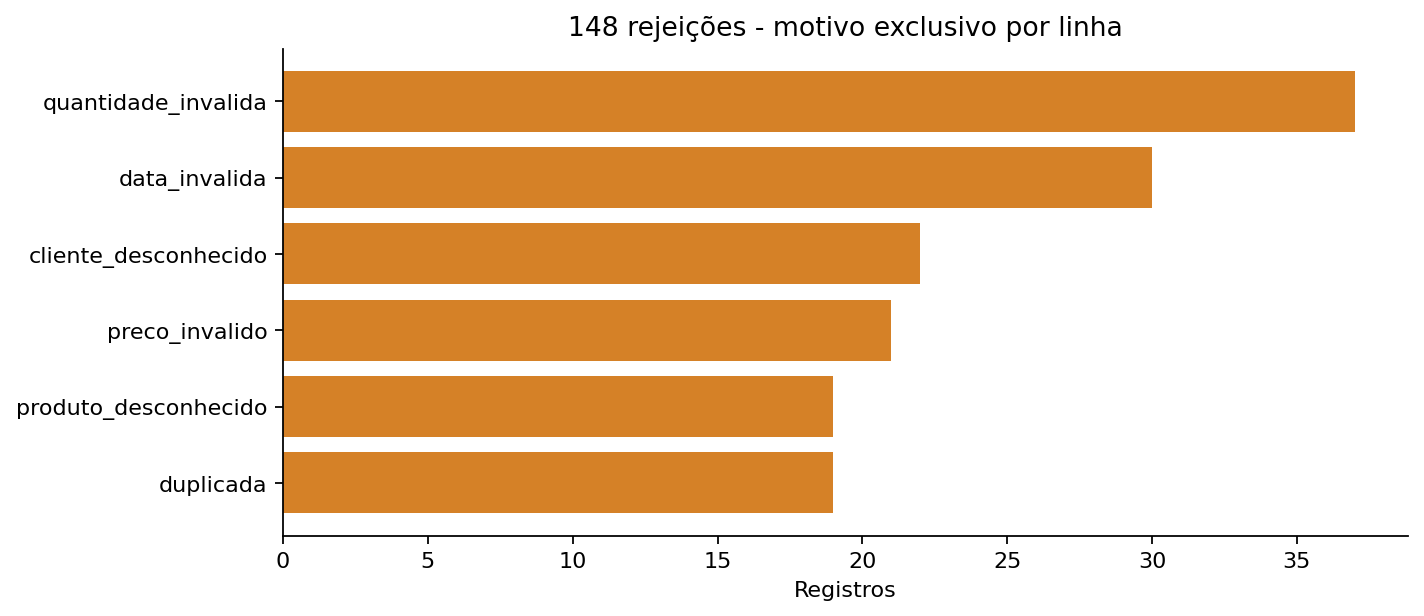

In [5]:
display(df[['quantidade','preco_unitario','valor_total']].describe())
for nome in ['01_target.png','02_temporal.png','03_municipios.png','04_produtos.png','05_limpeza.png']:
    display(Image(filename=str(ROOT/'graficos'/nome)))

## Preparação e engenharia de features
Atributos numéricos: mês, dia da semana/mês/ano, trimestre, fim de semana, seno/cosseno mensal e semanal, preço conhecido e históricos prévios de cliente, produto, município e média global suavizada.

Categorias: produto, categoria, segmento, município, UF e região imediata do IBGE. O código municipal é chave de integração, não grandeza numérica preditiva. IDs de cliente e venda são contexto técnico e não recebem one-hot.

Históricos de treino usam somente dias anteriores. Vendas no mesmo dia não veem os targets umas das outras. Teste em lote usa históricos congelados no fim do treino. Encoding e escala são ajustados exclusivamente no treino, inclusive em cada fold. Quantidade e valor_total são excluídos das entradas.

In [6]:
from src.features import NUMERIC,CATEGORICAL,CONTEXT
display(pd.DataFrame({'numericas':pd.Series(NUMERIC),'categoricas':pd.Series(CATEGORICAL)}))
display(pd.read_csv(ROOT/'resultados/features_train_antes_encoding.csv').head())
display(pd.read_csv(ROOT/'resultados/validacao_temporal.csv'))

,numericas,categoricas
0,mes,produto_id
1,dia_semana,categoria
2,dia_mes,segmento
3,dia_ano,municipio
4,trimestre,uf
5,fim_semana,regiao_imediata
6,mes_sin,NaN
7,mes_cos,NaN
8,semana_sin,NaN
9,semana_cos,NaN


,mes,dia_semana,dia_mes,dia_ano,trimestre,fim_semana,mes_sin,mes_cos,semana_sin,semana_cos,...,produto_vendas_previas,produto_media_qtd_previa,municipio_vendas_previas,global_media_qtd_previa,produto_id,categoria,segmento,municipio,uf,regiao_imediata
0,1,2,1,1,1,0,0.5,0.866025,0.974928,-0.222521,...,0,5.000000,0,5.000,P02,congelados,restaurante,Macapá,AP,Macapá
1,1,3,2,2,1,0,0.5,0.866025,0.433884,-0.900969,...,0,4.500000,0,4.500,P01,congelados,restaurante,Belém,PA,Belém
2,1,3,2,2,1,0,0.5,0.866025,0.433884,-0.900969,...,0,4.500000,0,4.500,P03,atacado,restaurante,Belém,PA,Belém
3,1,4,3,3,1,0,0.5,0.866025,-0.433884,-0.900969,...,0,4.375000,0,4.375,P05,complementos,restaurante,Santarém,PA,Santarém
4,1,4,3,3,1,0,0.5,0.866025,-0.433884,-0.900969,...,1,3.979167,0,4.375,P01,congelados,atacado,Santarém,PA,Santarém


,modelo,fold,treino_n,validacao_n,treino_fim,validacao_inicio,validacao_fim,MAE,RMSE,R2
0,Ridge,1,114,122,2025-03-16,2025-03-18,2025-05-27,3.389759,4.088126,-0.311566
1,Ridge,2,236,110,2025-05-27,2025-05-28,2025-08-01,3.126724,3.663916,-0.074553
2,Ridge,3,346,130,2025-08-01,2025-08-02,2025-10-16,2.964391,3.523000,-0.103415
3,RandomForest,1,114,122,2025-03-16,2025-03-18,2025-05-27,3.130444,3.603508,-0.019043
4,RandomForest,2,236,110,2025-05-27,2025-05-28,2025-08-01,3.114548,3.534251,0.000157
5,RandomForest,3,346,130,2025-08-01,2025-08-02,2025-10-16,2.980957,3.536565,-0.111929
6,HistGradientBoosting,1,114,122,2025-03-16,2025-03-18,2025-05-27,3.172622,3.676476,-0.060730
7,HistGradientBoosting,2,236,110,2025-05-27,2025-05-28,2025-08-01,3.154780,3.619245,-0.048511
8,HistGradientBoosting,3,346,130,2025-08-01,2025-08-02,2025-10-16,3.222399,3.861739,-0.325805
9,BaselineMedia,1,114,122,2025-03-16,2025-03-18,2025-05-27,3.190825,3.694288,-0.071034


## Modelos e avaliação
Ridge, Random Forest e HistGradientBoosting são comparados com DummyRegressor de média. Três folds temporais expansivos selecionam o modelo ML por MAE, sem consultar o teste. Dias completos não atravessam fronteiras. A avaliação final usa os 20% finais dos dias.

MAE e RMSE medem erro em unidades vendidas; RMSE penaliza mais erros grandes. R² compara com a média do conjunto avaliado e pode ser negativo. O baseline é relatado mesmo que supere o modelo ML escolhido. Não há busca de parâmetros usando o teste.

,modelo,CV_MAE_media,CV_MAE_desvio,MAE,RMSE,R2,selecionado_por_CV
0,Ridge,3.160292,0.175270,2.788392,3.445562,-0.331468,False
1,RandomForest,3.075316,0.067037,2.618156,3.222327,-0.164528,True
2,HistGradientBoosting,3.183267,0.028613,2.903426,3.625553,-0.474210,False
3,BaselineMedia,3.069293,0.140216,2.522964,3.038288,-0.035306,False


{'target': 'quantidade',
 'selecao': 'Menor MAE medio dos 3 folds temporais, entre os 3 modelos ML; baseline separado.',
 'modelo_selecionado': 'RandomForest',
 'seed': 42,
 'treino_n': 476,
 'teste_n': 116,
 'treino_inicio': '2025-01-01',
 'treino_fim': '2025-10-16',
 'teste_inicio': '2025-10-17',
 'teste_fim': '2025-12-31',
 'features_numericas': 18,
 'campos_categoricos': 6,
 'features_apos_encoding': 43,
 'comparacao': [{'modelo': 'Ridge',
   'CV_MAE_media': 3.160291551715375,
   'CV_MAE_desvio': 0.17527045173556985,
   'MAE': 2.788391519208226,
   'RMSE': 3.4455617974395656,
   'R2': -0.331468289627878,
   'selecionado_por_CV': False},
  {'modelo': 'RandomForest',
   'CV_MAE_media': 3.0753163524010865,
   'CV_MAE_desvio': 0.06703692947042239,
   'MAE': 2.618156032600295,
   'RMSE': 3.2223268667296945,
   'R2': -0.16452797329084268,
   'selecionado_por_CV': True},
  {'modelo': 'HistGradientBoosting',
   'CV_MAE_media': 3.1832669247435788,
   'CV_MAE_desvio': 0.028612883781978807,
 

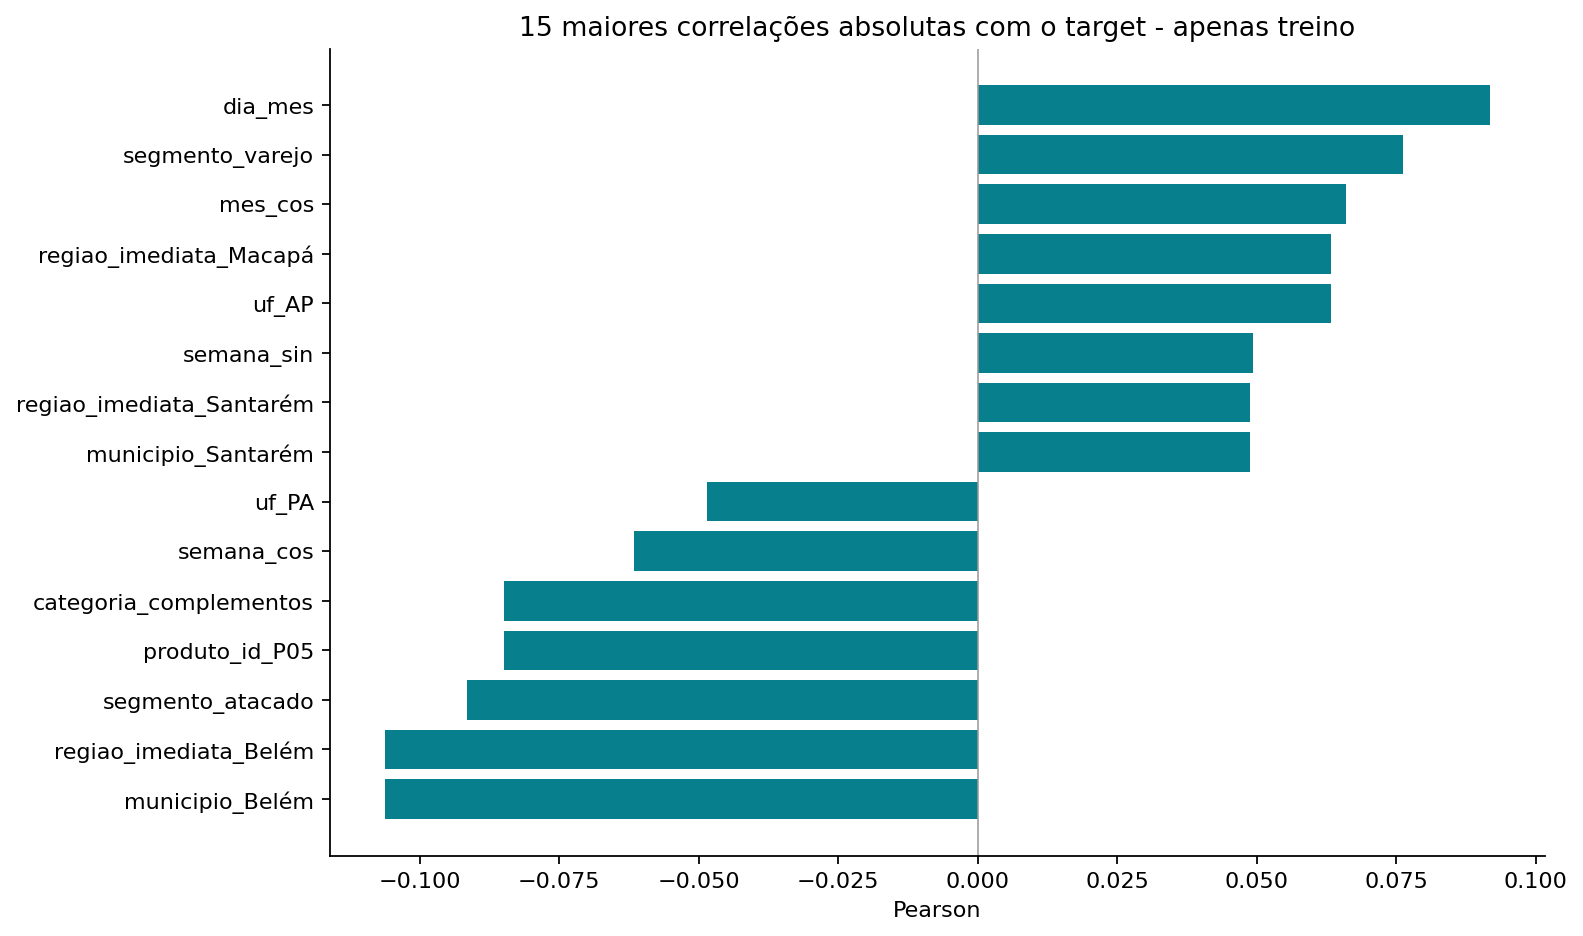

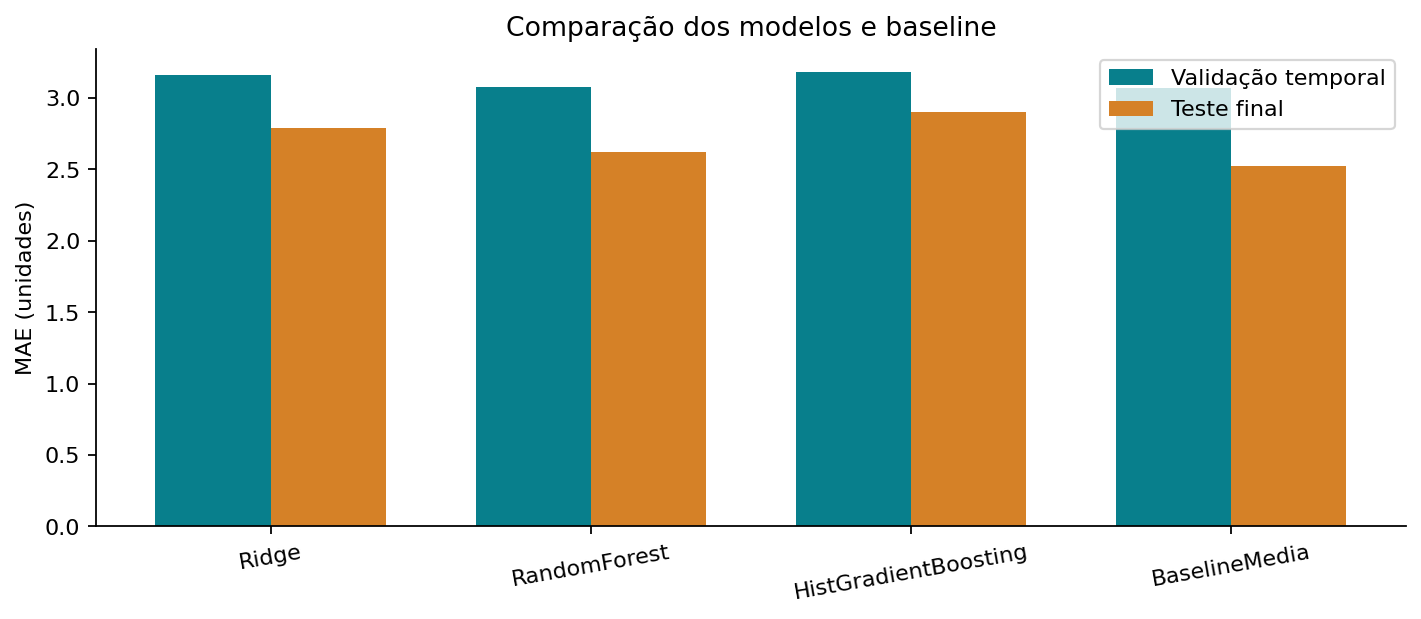

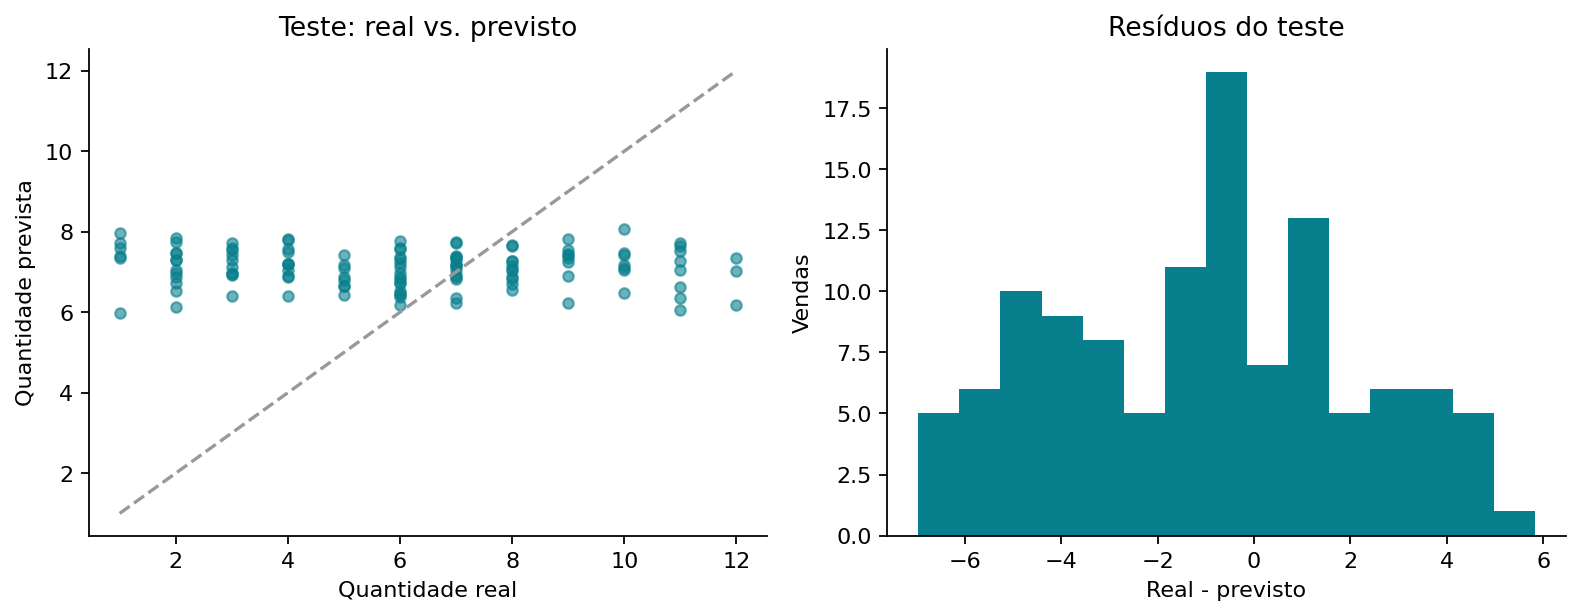

In [7]:
comparacao=pd.read_csv(ROOT/'resultados/comparacao_modelos.csv')
display(comparacao)
display(metricas)
for nome in ['06_correlacoes.png','07_modelos.png','08_residuos.png']:
    display(Image(filename=str(ROOT/'graficos'/nome)))

In [8]:
ml=comparacao[comparacao.selecionado_por_CV].iloc[0]
base=comparacao[comparacao.modelo=='BaselineMedia'].iloc[0]
print(f'Modelo ML escolhido por validação: {ml.modelo}; MAE teste={ml.MAE:.6f}; RMSE={ml.RMSE:.6f}; R²={ml.R2:.6f}')
print(f'Baseline média: MAE teste={base.MAE:.6f}; RMSE={base.RMSE:.6f}; R²={base.R2:.6f}')
print('Baseline supera o modelo ML em MAE no teste.' if base.MAE<ml.MAE else 'Modelo ML supera o baseline em MAE neste teste; não implica desempenho em dados reais.')

Modelo ML escolhido por validação: RandomForest; MAE teste=2.618156; RMSE=3.222327; R²=-0.164528
Baseline média: MAE teste=2.522964; RMSE=3.038288; R²=-0.035306
Baseline supera o modelo ML em MAE no teste.


## Verificações de causalidade e artefato
A verificação abaixo altera a quantidade de uma venda no treino e exige que as features até esse dia permaneçam iguais: o registro não pode ver seu próprio target nem targets do mesmo dia. O modelo serializado deve reproduzir as previsões salvas.

In [9]:
from sklearn.base import clone
from src.features import CausalFeatures
import numpy as np,pickle
X=pd.read_csv(ROOT/'resultados/X_train_contexto.csv')
y=pd.read_csv(ROOT/'resultados/y_train.csv').quantidade
i=len(X)//2; alterado=y.copy();alterado.iloc[i]+=100
F=CausalFeatures().fit_transform(X,y);G=CausalFeatures().fit_transform(X,alterado)
pd.testing.assert_frame_equal(F[X.data<=X.data.iloc[i]],G[X.data<=X.data.iloc[i]])
Xt=pd.read_csv(ROOT/'resultados/X_test_contexto.csv')
with (ROOT/'modelos/modelo_final.pkl').open('rb') as arquivo: artefato=pickle.load(arquivo)
previsto=artefato['pipeline'].predict(Xt)
np.testing.assert_allclose(previsto,pd.read_csv(ROOT/'resultados/previsoes_teste.csv').previsto,rtol=0,atol=1e-12)
assert 'quantidade' not in CONTEXT and 'valor_total' not in CONTEXT
assert X.data.max()<Xt.data.min()
print('Causalidade, separação temporal e recarga do modelo: verificadas.')

Causalidade, separação temporal e recarga do modelo: verificadas.


## Interpretação e limitações
A base simulada contém 592 transações válidas de 2025. A origem fictícia e a amostra pequena limitam a interpretação das relações. O IBGE oferece integridade cadastral e contexto geográfico, sem transformar as vendas em dados reais. Município/UF e região imediata têm redundância; sua inclusão não garante ganho de previsão.

O resultado deve ser interpretado em comparação com o baseline. Erro maior que o baseline e R² negativo não demonstram utilidade preditiva operacional. O modelo ML é salvo para demonstrar o processo; uma implantação dependeria de dados reais, nova validação e comparação com soluções simples.

Não foram criados targets artificiais nem novas vendas para inflar desempenho. Como o teste da M5 já era conhecido, esta P15 é uma extensão demonstrativa desse protocolo, e não um novo experimento independente com teste nunca observado.

## Entrega
Informar o link acessível do repositório Git no campo de texto do Moodle e anexar este notebook final.ipynb. O envio ao Moodle não é realizado pelo pipeline.